In [2]:
!pip install -Uq pymcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.1 MB/s eta 0:00:00


In [3]:
!pip install -Uq rebound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.6/830.6 kB 13.2 MB/s eta 0:00:00


In [4]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import rebound as rb
from astroquery.jplhorizons import Horizons
from astropy.time import Time

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


Consultando trayectoria desde 2025-05-09 hasta 2026-05-09...


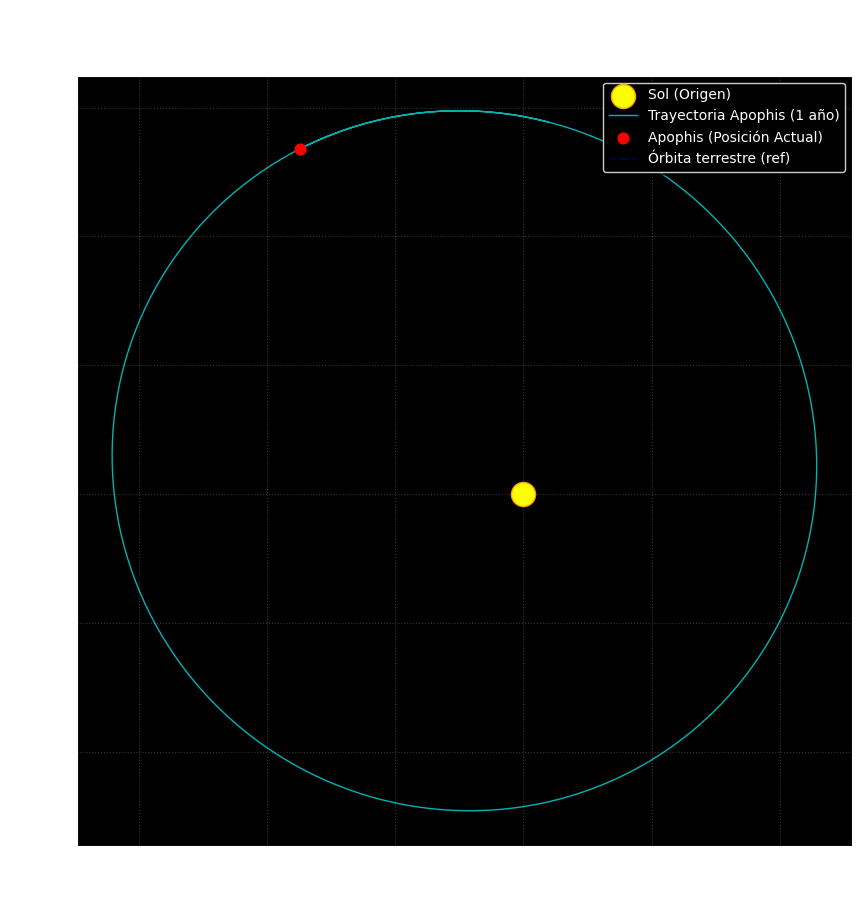

In [5]:
# 1. Configuración de fechas (Desde hoy hasta un año atrás)
# Usamos la fecha actual del sistema (2026)
fecha_final = datetime.now()
fecha_inicio = fecha_final - timedelta(days=365)

# Formateo de fechas para la consulta a JPL Horizons
start_str = fecha_inicio.strftime('%Y-%m-%d')
stop_str = fecha_final.strftime('%Y-%m-%d')

# 2. Consulta a JPL Horizons
# ID de Apophis: 99942
# location='@Sun' pone al Sol en el origen (0,0,0)
tabla, jd, X_raw = pc.consulta_horizons(
    id='99942',
    location='@Sun',
    epochs={'start': start_str, 'stop': stop_str, 'step': '1d'}
)

# 3. CORRECCIÓN DEL ERROR: Convertir a array de NumPy para evitar InvalidIndexError
X_total = np.array(X_raw)

# Extraer posiciones X e Y (están en las primeras dos columnas)
x_apophis = X_total[:, 0]
y_apophis = X_total[:, 1]

# 4. Generación de la gráfica 2D
plt.figure(figsize=(10, 10))
plt.style.use('dark_background') # Fondo espacial

# Dibujar al Sol en el centro
plt.scatter(0, 0, color='yellow', s=300, label='Sol (Origen)', edgecolors='orange', zorder=5)

# Dibujar la "estela" (toda la trayectoria del año)
plt.plot(x_apophis, y_apophis, color='cyan', linestyle='-', linewidth=1, alpha=0.7, label='Trayectoria Apophis (1 año)')

# Dibujar la posición actual de Apophis (el último punto registrado)
plt.scatter(x_apophis[-1], y_apophis[-1], color='red', s=60, label='Apophis (Posición Actual)', zorder=6)

# Añadir la órbita de la Tierra como referencia (Círculo de radio 1 UA aprox.)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color='blue', linestyle='--', alpha=0.3, label='Órbita terrestre (ref)')

# Personalización técnica de la gráfica
plt.title(f'Dinámica Orbital de Apophis (99942)\nReferencia: Heliocéntrica', fontsize=14, pad=20)
plt.xlabel('X [UA]', fontsize=12)
plt.ylabel('Y [UA]', fontsize=12)
plt.axis('equal') # Crucial para no deformar la elipse de la órbita
plt.grid(color='gray', linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=True, shadow=True)

In [6]:
fecha_inicio = '2026-03-11'

sim = rb.Simulation()
sim.units = ('yr', 'AU', 'Msun')
sim.add('Sun',date= fecha_inicio)
sim.add('Apophis',date= fecha_inicio)


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


/usr/local/lib/python3.12/dist-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


In [7]:
ts = np.linspace(0, 3.01, 100)
pos_apophis_helio1 = np.zeros((100, 3))


for i, t in enumerate(ts):
    sim.integrate(t)

    # Extraemos las partículas
    sol = sim.particles[0]
    apophis = sim.particles[1]

    # Calculamos la posición relativa (Heliocéntrica)
    x_rel = apophis.x - sol.x
    y_rel = apophis.y - sol.y
    z_rel = apophis.z - sol.z

    # Guardamos en nuestro arreglo
    pos_apophis_helio1[i] = [x_rel, y_rel, z_rel]


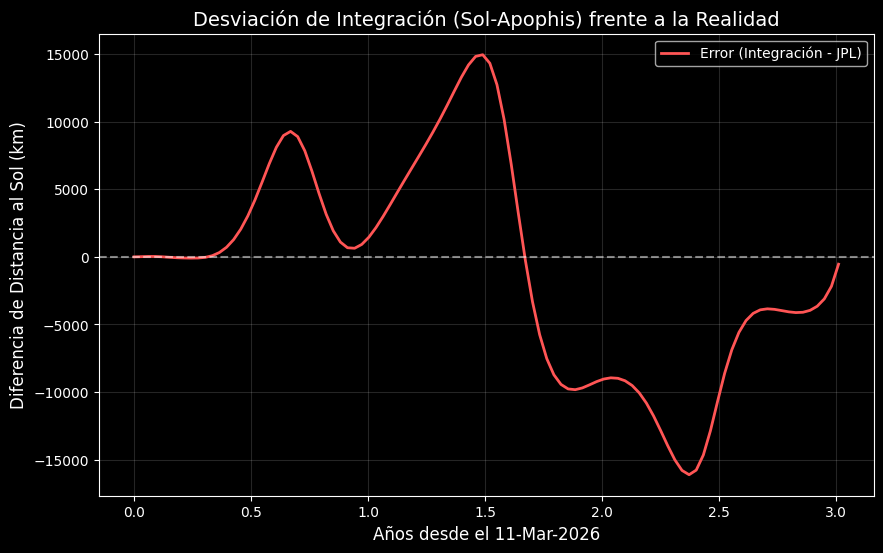

In [8]:
r_rebound_mag1 = np.linalg.norm(pos_apophis_helio1, axis=1)

# 2. Convertir tu tiempo 'ts' a Julian Dates (JD) para el JPL
# integración está en años (yr = 365.25 días)
jd_inicial = Time(fecha_inicio).jd
jds_integracion = jd_inicial + (ts * 365.25)

# 3. Descargar datos del JPL Horizons usando tus tiempos exactos
r_jpl_mag = []

# Dividimos tus 100 tiempos en dos bloques de 50
bloques_jd = [jds_integracion[:50], jds_integracion[50:]]

for bloque in bloques_jd:
    obj = Horizons(id='Apophis', location='@sun', epochs=bloque.tolist())
    vectores = obj.vectors()
    # Guardamos la columna 'range' (distancia al Sol)
    r_jpl_mag.extend(vectores['range'])

r_jpl_mag = np.array(r_jpl_mag)

# 4. Calcular la resta uno a uno (código vs Realidad)
diferencia1 = (r_rebound_mag1 - r_jpl_mag) * 1.5e8

# 5. Generar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(ts, diferencia1, color='#FF5555', linewidth=2, label='Error (Integración - JPL)')
plt.axhline(0, color='white', linestyle='--', alpha=0.5)

plt.title("Desviación de Integración (Sol-Apophis) frente a la Realidad", fontsize=14)
plt.xlabel("Años desde el 11-Mar-2026", fontsize=12)
plt.ylabel("Diferencia de Distancia al Sol (km)", fontsize=12)
plt.grid(True, alpha=0.15)
plt.legend()
plt.style.use('dark_background')
plt.show()

In [22]:
sim2 = rb.Simulation()
sim2.units = ('yr', 'AU', 'Msun')
sim2.add('Sun',date = fecha_inicio)
sim2.add('Apophis',date = fecha_inicio)
sim2.add('Jupiter', date = fecha_inicio)
sim2.add('Saturn', date = fecha_inicio)
sim2.add('EMB', date = fecha_inicio)
sim2.add('Venus', date = fecha_inicio)
sim2.add('Mercury', date = fecha_inicio)
sim2.add('Mars', date = fecha_inicio)
sim2.add('Neptune', date = fecha_inicio)
sim2.add('Uranus', date = fecha_inicio)


sim2.move_to_com()

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'EMB'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'EMB')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')


In [26]:
pos_apophis_helio2 = np.zeros((100, 3))
energia_total = np.zeros(len(ts))

for i, t in enumerate(ts):
    sim2.integrate(t)

    # Extraemos las partículas
    sol = sim2.particles[0]
    apophis = sim2.particles[1]

    # Calculamos la posición relativa (Heliocéntrica)
    x_rel = apophis.x - sol.x
    y_rel = apophis.y - sol.y
    z_rel = apophis.z - sol.z

    # Guardamos en nuestro arreglo
    pos_apophis_helio2[i] = [x_rel, y_rel, z_rel]

    energia_total[i] = sim2.energy()

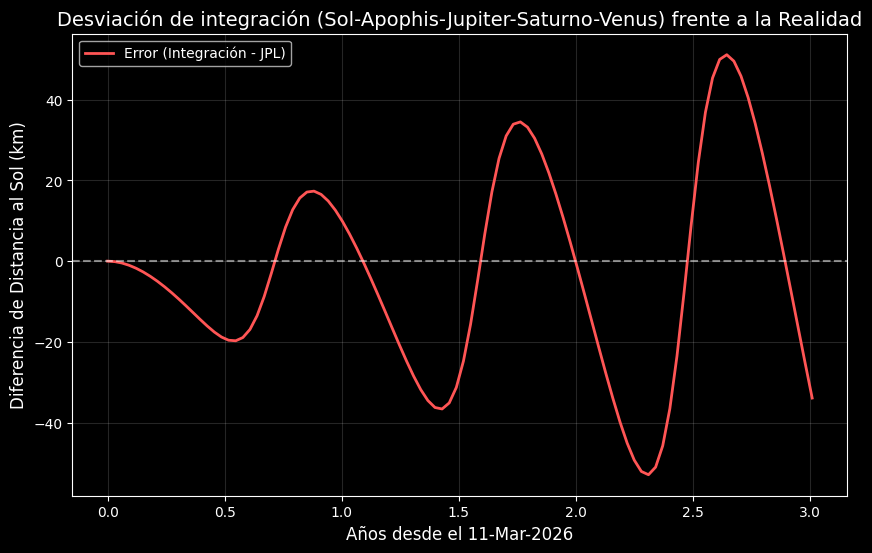

In [24]:
r_rebound_mag = np.linalg.norm(pos_apophis_helio2, axis=1)

# 4. Calcular la resta uno a uno (código vs Realidad)
diferencia2 = (r_rebound_mag - r_jpl_mag) * 1.5e8

# 5. Generar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(ts, diferencia2, color='#FF5555', linewidth=2, label='Error (Integración - JPL)')
plt.axhline(0, color='white', linestyle='--', alpha=0.5)

plt.title("Desviación de integración (Sol-Apophis-Jupiter-Saturno-Venus) frente a la Realidad", fontsize=14)
plt.xlabel("Años desde el 11-Mar-2026", fontsize=12)
plt.ylabel("Diferencia de Distancia al Sol (km)", fontsize=12)
plt.grid(True, alpha=0.15)
plt.legend()
plt.style.use('dark_background')
plt.show()

E = -0.004432583789208963


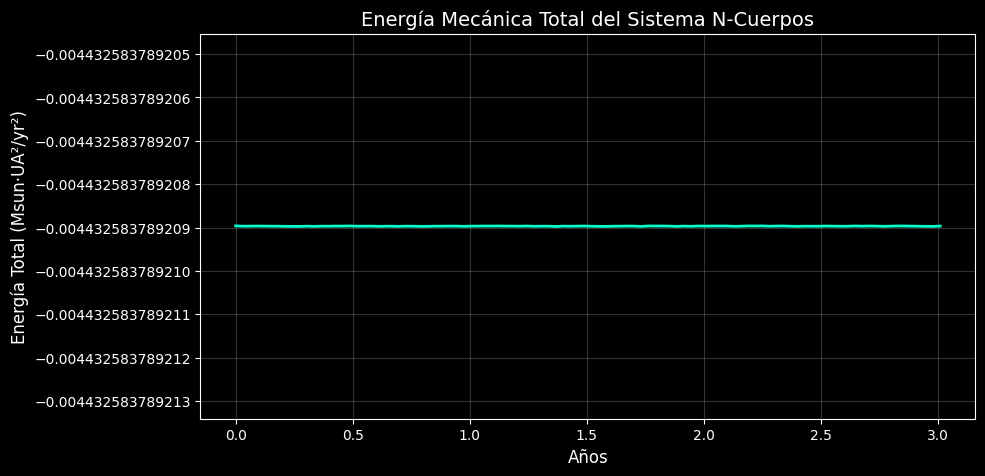

In [29]:
print(f'E = {energia_total[0]}')

# Gráfica de la Energía Total
plt.figure(figsize=(10, 5))
plt.plot(ts, energia_total, color='#00FFCC', linewidth=2)

plt.title("Energía Mecánica Total del Sistema N-Cuerpos", fontsize=14)
plt.xlabel("Años", fontsize=12)
plt.ylabel("Energía Total (Msun·UA²/yr²)", fontsize=12)

# Desactiva el offset de matplotlib para que no oculte los decimales si la línea es muy plana
plt.ticklabel_format(useOffset=False, style='plain')

plt.grid(True, alpha=0.2)
plt.style.use('dark_background')
plt.show()

G = 39.476926421373


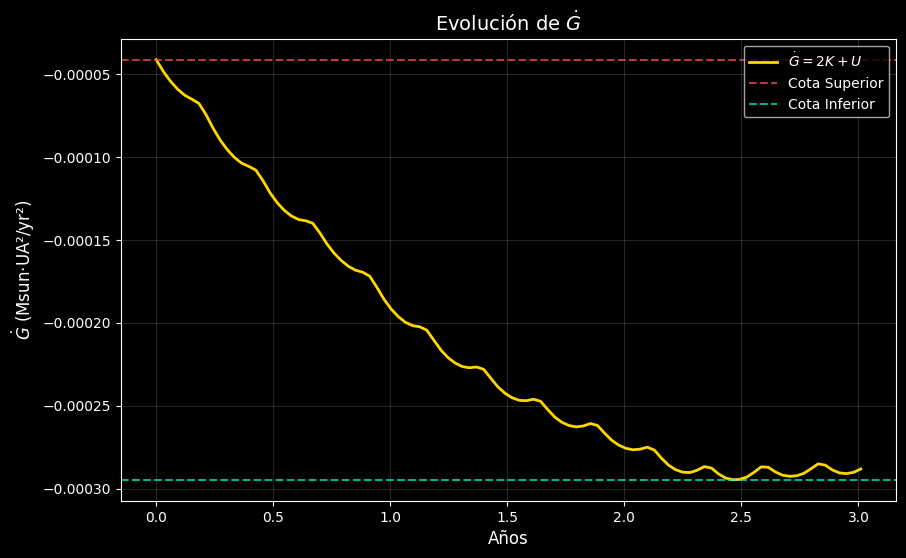

In [35]:
#Creamos arreglos para almacenar los datos
K_arr = np.zeros(len(ts))
U_arr = np.zeros(len(ts))
virial_punto_arr = np.zeros(len(ts)) # Esto es G punto (2K + U)

# Obtenemos la constante gravitacional en las unidades actuales (Msun, AU, yr)
G_constante = sim2.G

for i, t in enumerate(ts):
    sim2.integrate(t)

    K = 0.0
    U = 0.0
    num_particulas = len(sim2.particles)

    # Doble ciclo para calcular K de cada cuerpo y U de cada par
    for p in range(num_particulas):
        particula_1 = sim2.particles[p]

        # --- Cálculo de K manual ---
        v_cuadrado = particula_1.vx**2 + particula_1.vy**2 + particula_1.vz**2
        K += 0.5 * particula_1.m * v_cuadrado

        # --- Cálculo de U manual (Interacción por pares) ---
        for q in range(p + 1, num_particulas):
            particula_2 = sim2.particles[q]

            # Distancia euclidiana entre la partícula p y la partícula q
            dx = particula_1.x - particula_2.x
            dy = particula_1.y - particula_2.y
            dz = particula_1.z - particula_2.z
            distancia = np.sqrt(dx**2 + dy**2 + dz**2)

            # Potencial gravitacional entre este par
            U -= G_constante * (particula_1.m * particula_2.m) / distancia

    # Guardamos los valores en los arreglos
    K_arr[i] = K
    U_arr[i] = U
    virial_punto_arr[i] = 2 * K + U

print(f'G = {G_constante}')

#Gráfica de G punto (2K + U) oscilando
plt.figure(figsize=(10, 6))

plt.plot(ts, virial_punto_arr, color='#FFD700', linewidth=2, label=r'$\dot{G} = 2K + U$')

# Cotas (Máximo y Mínimo)
cota_max = np.max(virial_punto_arr)
cota_min = np.min(virial_punto_arr)
plt.axhline(cota_max, color='#FF5555', linestyle='--', alpha=0.7, label=f'Cota Superior')
plt.axhline(cota_min, color='#00FFCC', linestyle='--', alpha=0.7, label=f'Cota Inferior')

plt.title(r"Evolución de $\dot{G}$", fontsize=14)
plt.xlabel("Años", fontsize=12)
plt.ylabel(r"$\dot{G}$ (Msun·UA²/yr²)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.15)
plt.style.use('dark_background')
plt.show()